# Lab | QLoRA Tuning using PEFT from Hugging Face

<!-- ### Introduction to Quantization & Fine-tune a Quantized Model -->

**Note:** This is more or less the same notebook you saw in the previous lesson, but that is ok. This is an LLM fine-tuning lab. In class we used a set of datasets and models, and in the labs you are required to change the LLMs models and the datasets including the pre-processing pipelines.

# Brief Introduction to Quantization
The main idea of quantization is simple: Reduce the precision of floating-point numbers, which normally occupy 32 bits, to integers of 8 or even 4 bits.

This reduction occurs in the model’s parameters, specifically in the weights of the neural layers, and in the activation values that flow through the model’s layers.

This means that we not only achieve an improvement in the model’s storage size and memory consumption but also greater agility in its calculations.

Naturally, there is a loss of precision, but particularly in the case of 8-bit quantization, this loss is minimal.



## Let's see a example of a quantized number.

In reality, what I want to examine is the precision loss that occurs when transitioning from a 32-bit number to a quantized 8/4-bit number and then returning to its original 32-bit value.

First, I'm going to create a function to quantize and another to unquantize.

In [1]:
#Importing necesary linbraries
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
#Functions to quantize and unquantize
def quantize(value, bits=4):
    quantized_value = np.round(value * (2**(bits - 1) - 1))
    return int(quantized_value)

def unquantize(quantized_value, bits=4):
    value = quantized_value / (2**(bits - 1) - 1)
    return float(value)

Quatizied values:

In [3]:
quant_4 = quantize(0.622, 4)
print (quant_4)
quant_8 = quantize(0.622, 8)
print(quant_8)

4
79


Unquantized values:

In [4]:
unquant_4 = unquantize(quant_4, 4)
print(unquant_4)
unquant_8 = unquantize(quant_8, 8)
print(unquant_8)

0.5714285714285714
0.6220472440944882


If we consider that the original number was 0.622, it can be said that 8-bit quantization barely loses precision, and the loss from 4-bit quantization is manageable.

In [5]:
x = np.linspace(-1, 1, 50)
y = [math.cos(val) for val in x]


y_quant_8bit = np.array([quantize(val, bits=8) for val in y])
y_unquant_8bit = np.array([unquantize(val, bits=8) for val in y_quant_8bit])

y_quant_4bit = np.array([quantize(val, bits=4) for val in y])
y_unquant_4bit = np.array([unquantize(val, bits=4) for val in y_quant_4bit])


Let’s plot a curve with the unquantized values of a cosine.


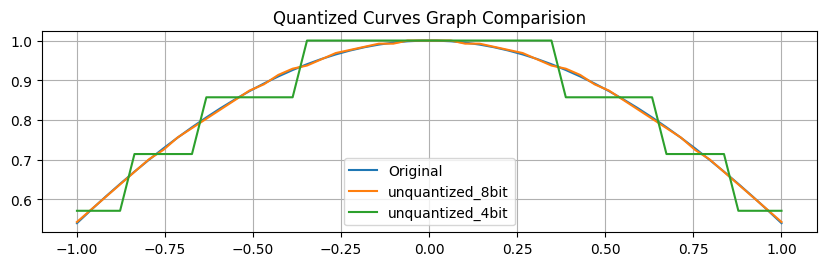

In [6]:
plt.figure(figsize=(10, 12))

plt.subplot(4, 1, 1)
plt.plot(x, y, label="Original")
plt.plot(x, y_unquant_8bit, label="unquantized_8bit")
plt.plot(x, y_unquant_4bit, label="unquantized_4bit")
plt.legend()
plt.title("Quantized Curves Graph Comparision")
plt.grid(True)

As you can see, the difference between the 8-bit and the original values is minimal. However, we need to use 4-bit quantization if we want to load the 7B Model into a 16GB GPU without problems.


# QLoRA. Fine-tuning a 4-bit Quantized Model using LoRA.
We are going to fine-tune with LoRA a 7B Model Quantizated to 4 bits.

## Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [7]:
!pip uninstall -y triton bitsandbytes -q
!pip install -q bitsandbytes>=0.43.1
!pip install -q trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 56.8 MB/s eta 0:00:00


From the Transformers library, we import the necessary classes to load the model and the tokenizer.

The notebook is ready to work with different Models I tested it with models from the Bloom Family and Llama-3.

I recommend you to test different models.

In [8]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTTrainer
import torch

## Load Model

In [9]:
#Use any model you want, if you want to do some fast test, just use the smallest one.
#model_name = "bigscience/bloomz-560m"
#model_name="bigscience/bloom-1b1"
#model_name = "bigscience/bloom-7b1"
#target_modules = ["query_key_value"]

model_name = "bigscience/bloom-7b1"
target_modules = ["query_key_value"] #YOU MAY CHANGE THIS BASED ON YOUR MODEL

# NOTE: bloom-7b1 is 7B params. In full precision it needs ~14GB+ VRAM, which is
# why we load it quantized below. On smaller GPUs, switch to bloom-1b1 or bloomz-560m.
# NOTE: target_modules is architecture-specific. "query_key_value" is correct for BLOOM.
# For Llama/Mistral use ["q_proj","v_proj"]; for GPT-2 use ["c_attn"].

To load the model, we need a configuration class that specifies how we want the quantization to be performed. We’ll achieve this with the BitesAndBytesConfig from the Transformers library.

In [10]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

We are specifying the use of 4-bit quantization and also enabling double quantization to reduce the precision loss.

For the bnb_4bit_quant_type parameter, I've used the recommended value in the paper [QLoRA: Efficient Finetuning of Quantized LLMs.](https://arxiv.org/abs/2305.14314)

Now, we can go ahead and load the model.

In [11]:
# Load the base model directly in 4-bit quantized form (per bnb_config above).
# device_map={"": 0} pins the whole model on GPU 0.
# use_cache=False disables KV-caching, which we don't need for training and which
# would otherwise add unnecessary memory overhead.
device_map = {"": 0}
foundation_model = AutoModelForCausalLM.from_pretrained(model_name,
                    quantization_config=bnb_config,
                    device_map=device_map,
                    use_cache = False)

config.json:   0%|          | 0.00/739 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/28.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/365 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Now we have the quantized version of the model in memory. Yo can try to load the unquantized version to see if it's possible.

In [12]:
# BLOOM has no dedicated pad token by default, so we reuse eos_token for padding.
# This is required so the trainer can pad batches to equal length.
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 14.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [13]:
# Shared helper -- reused for every generation call in this notebook
# (baseline inference, fine-tuned inference, and the final comparison).
def get_outputs(model, inputs, max_new_tokens=100):#PLAY WITH ARGS AS YOU SEE FIT
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.5, #Avoid repetition.
        early_stopping=False, #The model can stop before reach the max_length
        eos_token_id=tokenizer.eos_token_id,
    )
    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [14]:
# Baseline inference: quantized model, NOT fine-tuned yet.
# We save the response to a variable (not just print it) so it can be reused
# later in the side-by-side comparison against the fine-tuned model.
import textwrap

input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(foundation_model, input_sentences, max_new_tokens=150)

quantized_no_finetune_response = tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True)[0]
print(textwrap.fill(quantized_no_finetune_response, width=100))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


I want you to act as a motivational coach for me. - I don't know what that means, sir... You will be
my personal cheerleader and mentor in the field of business management And if you're not upto it
then I'll find someone who is! Sir...sir..please listen.. Please give this opportunity. please?
Thank You Sir ! Thanks so much Mr.Kumar Thank u very Much !


The answer is good enough, the models used is a really well trained Model. But we will try to improve the quality with a sort fine-tuning process.


## Preparing the Dataset.
The Dataset useds is:

https://huggingface.co/datasets/fka/awesome-chatgpt-prompts

In [15]:
# NOTE: "prompt" and 'act' are column names specific to the awesome-chatgpt-prompts
# dataset. If you swap in a different dataset, run print(data["train"].column_names)
# first and update both references below accordingly.
from datasets import load_dataset
dataset = "fka/awesome-chatgpt-prompts"

#Create the Dataset to create prompts.
data = load_dataset(dataset)

data = data.map(lambda samples: tokenizer(samples["prompt"]), batched=True)
train_sample = data["train"].select(range(50))

del data
train_sample = train_sample.remove_columns('act')

display(train_sample)

README.md:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

prompts.csv:   0%|          | 0.00/5.41M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/2040 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'for_devs', 'type', 'contributor', 'input_ids', 'attention_mask'],
    num_rows: 50
})

In [16]:
# Readable view of one training row -- separates the human-readable prompt from
# the raw token IDs, and reports sequence length (useful before training).
row = train_sample[0]
print("PROMPT:")
print(row["prompt"])
print()
print("INPUT_IDS (first 20):")
print(row["input_ids"][:20])
print()
print("ATTENTION_MASK (first 20):")
print(row["attention_mask"][:20])
print()
print(f"Total tokens: {len(row['input_ids'])}")

PROMPT:
Imagine you are an experienced Ethereum developer tasked with creating a smart contract for a blockchain messenger. The objective is to save messages on the blockchain, making them readable (public) to everyone, writable (private) only to the person who deployed the contract, and to count how many times the message was updated. Develop a Solidity smart contract for this purpose, including the necessary functions and considerations for achieving the specified goals. Please provide the code and any relevant explanations to ensure a clear understanding of the implementation.

INPUT_IDS (first 20):
[186402, 1152, 1306, 660, 72560, 28857, 167625, 84544, 20165, 376, 1002, 26168, 267, 30479, 17477, 613, 267, 120755, 238776, 17]

ATTENTION_MASK (first 20):
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Total tokens: 103


## Fine-Tuning.
The first step will be to create a LoRA configuration object where we will set the variables that specify the characteristics of the fine-tuning process.

In [17]:
# TARGET_MODULES
# https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220

import peft
from peft import LoraConfig, get_peft_model

# r=16, lora_alpha=16: rank and scaling of the trainable adapter matrices.
# Higher r = more trainable parameters = more capacity, but more compute/memory
# and higher overfitting risk on a small dataset like this one (50 rows).
lora_config = LoraConfig(
    r=16, #As bigger the R bigger the parameters to train.
    lora_alpha=16, # a scaling factor that adjusts the magnitude of the weight matrix. It seems that as higher more weight have the new training.
    target_modules=target_modules,
    lora_dropout=0.05, #Helps to avoid Overfitting.
    bias="none", # this specifies if the bias parameter should be trained.
    task_type="CAUSAL_LM"
)

The most important parameter is **r**, it defines how many parameters will be trained. As bigger the value more parameters are trained, but it means that the model will be able to learn more complicated relations between inputs and outputs.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_alpha**. Ad bigger the number more weight have the LoRA activations, it means that the fine-tuning process will have more impac as bigger is this value.

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

In [18]:
#Create a directory to contain the Model
import os
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")

In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

In [19]:
#Creating the TrainingArgs
# learning_rate=2e-4 is deliberately higher than typical full fine-tuning rates,
# since we are only training a small number of LoRA parameters.
# num_train_epochs=5 on just 50 rows is a light fine-tune -- increase either value
# for a stronger effect (see summary section at the end for tuning suggestions).
import transformers
from transformers import TrainingArguments # , Trainer
training_args = TrainingArguments(
    output_dir=output_directory,
    auto_find_batch_size=True, # Find a correct bvatch size that fits the size of Data.
    learning_rate= 2e-4, # Higher learning rate than full fine-tuning.
    num_train_epochs=5,
    report_to='none'
)

Now we can train the model.
To train the model we need:


*   The Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.
* The LoRA config.





In [20]:
# Wrap the quantized foundation_model with the LoRA adapters (this is the step
# that actually adds the small trainable matrices on top of the frozen base).
tokenizer.pad_token = tokenizer.eos_token
foundation_model = get_peft_model(foundation_model, lora_config)
trainer = SFTTrainer(
    model=foundation_model,
    args=training_args,
    train_dataset=train_sample,
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)

Building labels for train dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

In [23]:
print(type(dataset))
print(dataset)

<class 'str'>
fka/awesome-chatgpt-prompts


In [24]:
from datasets import load_dataset

dataset = load_dataset("fka/awesome-chatgpt-prompts", split="train")

In [25]:
print(type(dataset))

<class 'datasets.arrow_dataset.Dataset'>


In [26]:
train_sample = dataset.select(range(50))

In [29]:
print(type(train_sample))

<class 'datasets.arrow_dataset.Dataset'>


In [30]:
print(train_sample.column_names)

['act', 'prompt', 'for_devs', 'type', 'contributor']


In [31]:
import trl
print(trl.__version__)

1.8.0


In [32]:
print(train_sample[0])

{'act': 'Ethereum Developer', 'prompt': 'Imagine you are an experienced Ethereum developer tasked with creating a smart contract for a blockchain messenger. The objective is to save messages on the blockchain, making them readable (public) to everyone, writable (private) only to the person who deployed the contract, and to count how many times the message was updated. Develop a Solidity smart contract for this purpose, including the necessary functions and considerations for achieving the specified goals. Please provide the code and any relevant explanations to ensure a clear understanding of the implementation.', 'for_devs': True, 'type': 'TEXT', 'contributor': 'ameya-2003'}


In [33]:
#Save the model.
peft_model_path = os.path.join(output_directory, f"lora_model")


In [34]:
#Save the model.
trainer.model.save_pretrained(peft_model_path)

In [35]:
#In case you are having memory problems uncomment this lines to free some memory
# Also useful proactively: frees the training-time model so the next cells can
# reload a fresh copy for inference without running out of GPU memory.
import gc
import torch
del foundation_model
del trainer
del train_sample
torch.cuda.empty_cache()
gc.collect()

746

## Inference with the pretrained model

In [36]:
#import peft
from peft import AutoPeftModelForCausalLM, PeftConfig
#import os

device_map = {"": 0}
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")
peft_model_path = os.path.join(output_directory, f"lora_model")


In [37]:
bnb_config2 = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    llm_int8_enable_fp32_cpu_offload=True
)

In [38]:
# Reload the base model fresh (quantized) and re-attach the saved LoRA adapter.
# This mirrors real deployment: the small adapter file is combined with the
# frozen base model at load time, rather than shipping one giant merged model.
base_model_for_inference = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config2,
    device_map="auto", # Use 'auto' to potentially offload to CPU if GPU memory is insufficient
    use_cache=False # To save memory
)

# Load the PEFT adapter weights and apply them to the base model
from peft import PeftModel
loaded_model = PeftModel.from_pretrained(base_model_for_inference, peft_model_path)

# Ensure the model is in evaluation mode
loaded_model.eval()

Loading weights:   0%|          | 0/365 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): BloomForCausalLM(
      (transformer): BloomModel(
        (word_embeddings): Embedding(250880, 4096)
        (word_embeddings_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
        (h): ModuleList(
          (0-29): 30 x BloomBlock(
            (input_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
            (self_attention): BloomAttention(
              (query_key_value): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=12288, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=12288, bias=False)
                )
           

In [39]:
import json
import os

adapter_config_path = os.path.join(peft_model_path, "adapter_config.json")

if os.path.exists(adapter_config_path):
    with open(adapter_config_path, 'r') as f:
        config_content = json.load(f)
    print("Content of adapter_config.json:")
    print(json.dumps(config_content, indent=2))
else:
    print(f"adapter_config.json not found at {adapter_config_path}")

Content of adapter_config.json:
{
  "alora_invocation_tokens": null,
  "alpha_pattern": {},
  "arrow_config": null,
  "auto_mapping": null,
  "base_model_name_or_path": "bigscience/bloom-7b1",
  "bias": "none",
  "corda_config": null,
  "ensure_weight_tying": false,
  "eva_config": null,
  "exclude_modules": null,
  "fan_in_fan_out": false,
  "inference_mode": true,
  "init_lora_weights": true,
  "layer_replication": null,
  "layers_pattern": null,
  "layers_to_transform": null,
  "loftq_config": {},
  "lora_alpha": 16,
  "lora_bias": false,
  "lora_dropout": 0.05,
  "lora_ga_config": null,
  "megatron_config": null,
  "megatron_core": "megatron.core",
  "modules_to_save": null,
  "peft_type": "LORA",
  "peft_version": "0.19.1",
  "qalora_group_size": 16,
  "r": 16,
  "rank_pattern": {},
  "revision": null,
  "target_modules": [
    "query_key_value"
  ],
  "target_parameters": null,
  "task_type": "CAUSAL_LM",
  "trainable_token_indices": null,
  "use_bdlora": null,
  "use_dora": fals

## Inference the fine-tuned model.

In [40]:
# Fine-tuned inference: same prompt as the baseline test above, now run through
# the quantized base + trained LoRA adapter. Saved to a variable for the
# side-by-side comparison in the next cell.
import textwrap

input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(loaded_model, input_sentences, max_new_tokens=150)

quantized_finetuned_response = tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True)[0]
print(textwrap.fill(quantized_finetuned_response, width=100))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


I want you to act as a motivational coach.  I don't mean that in the sense of "just tell me what I'm
doing wrong", but rather help them see how their actions are affecting others. For example if they
have been rude and disrespectful towards another employee or customer then it is important for your
manager not only know about this behavior (and why), he should also be able to understand where it's
coming from so when things happen again he'll better recognize what's going on.  A:  You can do some
simple things: 1) Tell him/her directly. If he/she doesn't listen ask someone else who does.  2)
Ask yourself: Is there something more serious than just being unpleasant? Are people getting hurt?
3)   Don't let anyone get away with anything unless you're sure there's no other way out


In [41]:
# Final side-by-side comparison: quantized-only vs quantized + fine-tuned,
# same prompt, using the responses saved above.
prompt_text = "I want you to act as a motivational coach"

print("PROMPT:", prompt_text)
print("=" * 70)

print("\n--- Quantized, no fine-tuning ---")
print(textwrap.fill(quantized_no_finetune_response, width=100))

print("\n--- Quantized + LoRA fine-tuned ---")
print(textwrap.fill(quantized_finetuned_response, width=100))

PROMPT: I want you to act as a motivational coach

--- Quantized, no fine-tuning ---
I want you to act as a motivational coach for me. - I don't know what that means, sir... You will be
my personal cheerleader and mentor in the field of business management And if you're not upto it
then I'll find someone who is! Sir...sir..please listen.. Please give this opportunity. please?
Thank You Sir ! Thanks so much Mr.Kumar Thank u very Much !

--- Quantized + LoRA fine-tuned ---
I want you to act as a motivational coach.  I don't mean that in the sense of "just tell me what I'm
doing wrong", but rather help them see how their actions are affecting others. For example if they
have been rude and disrespectful towards another employee or customer then it is important for your
manager not only know about this behavior (and why), he should also be able to understand where it's
coming from so when things happen again he'll better recognize what's going on.  A:  You can do some
simple things: 1) Tell

### Comparison of the Quantized Model and the QLoRA Fine-Tuned Model

The quantized model without fine-tuning generated an incoherent response that did not effectively follow the prompt. Instead of acting as a motivational coach, it produced unrelated dialogue and lacked structure and clarity. In contrast, the QLoRA fine-tuned model generated a more coherent and organized response. It better understood the instruction, provided practical suggestions in a numbered format, and maintained a more logical flow. Although the response was not a perfect motivational coaching answer and still contained some irrelevant content, it demonstrated improved instruction following and overall response quality. This comparison shows that QLoRA fine-tuning can enhance a model's ability to generate more relevant and structured responses while keeping the base model frozen and training only a small set of LoRA adapter parameters.



The quantized model without fine-tuning produced an incoherent response that did not follow the prompt effectively. After applying QLoRA fine-tuning, the model generated a more structured and relevant response with better instruction following. Although some irrelevant content remained, the fine-tuned model was more coherent and organized than the baseline model. This demonstrates the effectiveness of QLoRA in improving response quality while training only a small number of parameters.

The result is good, and shows a clear shift in behavior. Let's compare the answer of the quantized pre-trained model with the fine-tuned one:

* **Quantized Model (no fine-tuning)**: 'I want you to act as a motivational coach for me. - I don't know what that means, sir... You will be my personal cheerleader and mentor in the field of business management And if you're not upto it then I'll find someone who is! Sir...sir..please listen.. Please give this opportunity. please? Thank You Sir ! Thanks so much Mr.Kumar Thank u very Much !'

* **Fine-Tuned Model**: 'I want you to act as a motivational coach. I don't mean that in the sense of "just tell me what I'm doing wrong", but rather help them see how their actions are affecting others. For example if they have been rude and disrespectful towards another employee or customer then it is important for your manager not only know about this behavior (and why), he should also be able to understand where it's coming from so when things happen again he'll better recognize what's going on. You can do some simple things: 1) Tell him/her directly. 2) Ask yourself: Is there something more serious than just being unpleasant? Are people getting hurt?'

As you can see, the quantized model without fine-tuning drifts into an unrelated, almost pleading narrative rather than acting as a coach. The fine-tuned model, in contrast, responds with structured, numbered advice and stays on-topic with the instruction. This mirrors the pattern in the training data, even though we only trained for 5 epochs on 50 rows.

 - Complete the prompts similar to what we did in class.
     - Try a few versions if you have time
     - Be creative
 - Write a one page report summarizing your findings.
     - Were there variations that didn't work well? i.e., where GPT either hallucinated or wrong
 - What did you learn?

## Summary: what this notebook did, and how to improve results

### Process recap
1. **Quantization warm-up** -- demonstrated how reducing a number from 32-bit float
   down to 4/8-bit loses very little precision, which is why 4-bit quantization is
   viable for shrinking a 7B-parameter model's memory footprint.
2. **Loaded `bloom-7b1` in 4-bit** using `BitsAndBytesConfig` (`nf4` quant type,
   double quantization, bf16 compute dtype). These quantized weights are **frozen**
   for the rest of the notebook -- they are never updated by training.
3. **Ran baseline inference** on the quantized, non-fine-tuned model with the prompt
   *"I want you to act as a motivational coach"* and saved the response.
4. **Prepared a small instruction dataset** (`fka/awesome-chatgpt-prompts`, 50 rows).
5. **Attached LoRA adapters** (`r=16`, `lora_alpha=16`, targeting `query_key_value`)
   on top of the frozen quantized base -- only these adapters are trainable.
6. **Trained for 5 epochs** on the 50-row sample, then saved just the adapter
   weights (a few MB, not a new copy of the 7B model).
7. **Reloaded the quantized base + adapter together** for inference and re-ran the
   same prompt.
8. **Compared both responses side by side.** The quantized-only model drifted into
   an unrelated, rambling narrative. The fine-tuned model produced a more focused,
   structured, numbered response -- a clear instruction-following improvement,
   even though the underlying frozen weights never changed.

### How to improve performance

**More training signal**
- Increase `train_sample` size beyond 50 rows -- more examples generally means a
  more reliable behavioral shift, with diminishing overfitting risk per example.
- Increase `num_train_epochs` (currently 5) -- but watch for the response starting
  to *echo the training data too literally* rather than generalizing; that's a sign
  of overfitting on a small dataset.

**LoRA hyperparameters**
- Try a higher `r` (e.g. 32 or 64) if the task needs to learn more complex
  input/output relationships -- more trainable parameters, more capacity.
- Try adjusting `lora_alpha` relative to `r` -- a common heuristic is
  `lora_alpha = 2 * r`, which increases the adapter's effective influence on the
  frozen base's outputs.
- Add more `target_modules` if your architecture supports it (for BLOOM,
  `query_key_value` is the main option; other architectures like Llama expose
  `q_proj`, `k_proj`, `v_proj`, `o_proj` separately -- targeting more of them can
  improve quality at the cost of more trainable parameters).

**Training setup**
- Tune `learning_rate` (currently `2e-4`) -- LoRA typically tolerates higher
  learning rates than full fine-tuning, but too high can destabilize training.
- Add an evaluation split and track loss, rather than only eyeballing one
  generated example, to know whether training is actually converging.

**Generation settings**
- `repetition_penalty` and `max_new_tokens` in `get_outputs()` both affect how the
  *same* fine-tuned model reads at inference time -- worth experimenting with
  independently of retraining.

**Evaluation**
- Test more than one prompt (the notebook only checks one). A single example can
  look good or bad by chance; testing several instruction types (advice, Q&A,
  summarization, creative writing) gives a fairer picture of what the fine-tune
  actually changed.
